In [1]:
# ============================================================
# Train_Price_Multistep_Extended.ipynb
# Extend Green Leaf Price Forecast from 7 → 30 days
#
# Strategy: Direct Multi-Horizon (same as Task_B)
# Day+1 to Day+7 already exist and are NOT touched
# ============================================================

import os

# These folders already exist but makedirs is safe
os.makedirs('saved_models/multistep', exist_ok=True)
os.makedirs('plots/multistep_extended', exist_ok=True)
os.makedirs('results/multistep_extended', exist_ok=True)

print("="*60)
print("   SmartTea AI — Price Forecast Extension")
print("   7 days → 30 days")
print("="*60)
print()
print("   WHAT THIS NOTEBOOK DOES:")
print("   → Loads tea_price_regression.csv")
print("   → Trains Linear Regression for Day+8 to Day+30")
print("   → Day+1 to Day+7 are NOT retrained (already good)")
print("   → Saves new models to saved_models/multistep/")
print("   → Updates metadata for API")
print()
print("   EXPECTED TIME: 3-5 minutes (LR trains fast)")
print()
print("✅ Setup complete!")

   SmartTea AI — Price Forecast Extension
   7 days → 30 days

   WHAT THIS NOTEBOOK DOES:
   → Loads tea_price_regression.csv
   → Trains Linear Regression for Day+8 to Day+30
   → Day+1 to Day+7 are NOT retrained (already good)
   → Saves new models to saved_models/multistep/
   → Updates metadata for API

   EXPECTED TIME: 3-5 minutes (LR trains fast)

✅ Setup complete!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_absolute_error,
                             mean_squared_error,
                             r2_score)
import joblib
import json

plt.style.use('seaborn-v0_8-darkgrid')

print("="*50)
print("   LIBRARIES LOADED")
print("="*50)
import sklearn
import xgboost as xgb
print(f"   scikit-learn : {sklearn.__version__}")
print(f"   xgboost      : {xgb.__version__}")
print(f"   pandas       : {pd.__version__}")
print(f"   numpy        : {np.__version__}")
print("="*50)
print("✅ Ready!")

   LIBRARIES LOADED
   scikit-learn : 1.9.0
   xgboost      : 3.2.0
   pandas       : 3.0.3
   numpy        : 2.4.6
✅ Ready!


In [3]:
# ============================================================
# All settings in one place
# ============================================================

# Horizons that ALREADY EXIST (do not retrain these)
EXISTING_HORIZONS = list(range(1, 8))    # 1,2,3,4,5,6,7

# NEW horizons we want to add
NEW_HORIZONS = list(range(8, 31))        # 8,9,...,30

# All horizons combined (for final evaluation)
ALL_HORIZONS = list(range(1, 31))        # 1 to 30

# Features (must be identical to Task_B — DO NOT CHANGE)
FEATURE_COLS = [
    'Month', 'DayOfWeek', 'Quarter',
    'IsWeekend', 'DayOfYear', 'Day',
    'GreenLeafPricePerKgLKR',
    'PriceLag1', 'PriceLag2', 'PriceLag3',
    'PriceLag7', 'PriceLag14',
    'PriceRollingMean7', 'PriceRollingMean30',
    'PriceRollingStd7', 'PriceChangePct',
    'GreenLeafQuantityKg', 'QtyRollingMean7',
    'FirewoodCollectedKg', 'FirewoodCostPerKgLKR',
    'TotalDailyCostLKR',
    'TemperatureCelsius', 'RainfallMM', 'HeavyRainFlag',
    'SupplierDelivered', 'SupplierQuantityKg',
    'PromotionActive', 'MonthStartBonus',
]

print("="*55)
print("   CONFIGURATION")
print("="*55)
print(f"   Existing horizons (skip): {EXISTING_HORIZONS}")
print(f"   New horizons (train):     {NEW_HORIZONS}")
print(f"   Total after upgrade:      Day+1 to Day+30")
print(f"   Features:                 {len(FEATURE_COLS)}")
print()
print("   IMPORTANT:")
print("   The scaler from Task_B will be REUSED")
print("   The same scaler must be used for consistency")
print("   We load it from saved_models/multistep/scaler.pkl")
print("="*55)
print()
print("✅ Config ready!")

   CONFIGURATION
   Existing horizons (skip): [1, 2, 3, 4, 5, 6, 7]
   New horizons (train):     [8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
   Total after upgrade:      Day+1 to Day+30
   Features:                 28

   IMPORTANT:
   The scaler from Task_B will be REUSED
   The same scaler must be used for consistency
   We load it from saved_models/multistep/scaler.pkl

✅ Config ready!


In [4]:
# Load dataset
df = pd.read_csv('data/tea_price_regression.csv')
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)

print("="*60)
print("   DATASET LOADED")
print("="*60)
print(f"   File   : tea_price_regression.csv")
print(f"   Rows   : {len(df):,}")
print(f"   Period : {df['Date'].min().date()} "
      f"→ {df['Date'].max().date()}")
print()

# Verify all required feature columns exist
missing = [c for c in FEATURE_COLS if c not in df.columns]
if missing:
    print(f"❌ MISSING COLUMNS: {missing}")
    print("   Check your dataset column names!")
else:
    print(f"✅ All {len(FEATURE_COLS)} feature columns found")

# Check target column exists
target_col = 'GreenLeafPricePerKgLKR'
if target_col in df.columns:
    print(f"✅ Target column found: {target_col}")
else:
    print(f"❌ Target column missing: {target_col}")

print()
print(f"   Price range: {df[target_col].min():.2f} "
      f"→ {df[target_col].max():.2f} LKR/kg")
print(f"   Price mean:  {df[target_col].mean():.2f} LKR/kg")
print()
print("✅ Data verified!")

   DATASET LOADED
   File   : tea_price_regression.csv
   Rows   : 1,065
   Period : 2021-01-30 → 2023-12-30

✅ All 28 feature columns found
✅ Target column found: GreenLeafPricePerKgLKR

   Price range: 79.49 → 131.88 LKR/kg
   Price mean:  101.93 LKR/kg

✅ Data verified!


In [5]:
# ============================================================
# Build target columns for ALL 30 horizons
# Then load the EXISTING scaler from Task_B
# ============================================================

# Build shifted target columns
# Target_h = price h days in the future
df_ms = df.copy()

for h in ALL_HORIZONS:
    df_ms[f'Target_{h}'] = (
        df_ms['GreenLeafPricePerKgLKR'].shift(-h)
    )

# Drop rows where any target is NaN
# (last 30 rows will have missing targets)
df_ms = df_ms.dropna(
    subset=[f'Target_{h}' for h in ALL_HORIZONS]
).reset_index(drop=True)

print("="*60)
print("   TARGETS BUILT")
print("="*60)
print(f"   Rows after dropping NaN: {len(df_ms):,}")
print()
print("   Sample targets (first row):")
for h in [1, 7, 14, 21, 30]:
    val = df_ms[f'Target_{h}'].iloc[0]
    print(f"   Target_{h:<3} (Day+{h:<3}): {val:.2f} LKR/kg")

print()

# ── Load existing scaler from Task_B ──────────────────────
# CRITICAL: must use the SAME scaler for consistency
# If we create a new scaler, the existing Day+1..7
# models will give wrong predictions

SCALER_PATH = 'saved_models/multistep/scaler.pkl'

if os.path.exists(SCALER_PATH):
    existing_scaler = joblib.load(SCALER_PATH)
    print(f"✅ Existing scaler loaded from:")
    print(f"   {SCALER_PATH}")
    print()
    print("   This scaler was used to train Day+1 to Day+7")
    print("   We MUST reuse it for Day+8 to Day+30")
    print("   Using a different scaler would break consistency")
else:
    print("❌ Scaler not found!")
    print(f"   Expected at: {SCALER_PATH}")
    print("   Check your saved_models/multistep/ folder")

print()
print("✅ Ready for train/test split!")

   TARGETS BUILT
   Rows after dropping NaN: 1,035

   Sample targets (first row):
   Target_1   (Day+1  ): 90.26 LKR/kg
   Target_7   (Day+7  ): 93.33 LKR/kg
   Target_14  (Day+14 ): 94.02 LKR/kg
   Target_21  (Day+21 ): 94.48 LKR/kg
   Target_30  (Day+30 ): 100.26 LKR/kg

✅ Existing scaler loaded from:
   saved_models/multistep/scaler.pkl

   This scaler was used to train Day+1 to Day+7
   We MUST reuse it for Day+8 to Day+30
   Using a different scaler would break consistency

✅ Ready for train/test split!


In [6]:
# ============================================================
# Chronological 80/20 split
# match Task_B exactly so models are comparable
# ============================================================

SPLIT_RATIO = 0.80
split_idx   = int(len(df_ms) * SPLIT_RATIO)

X_all = df_ms[FEATURE_COLS]
dates = df_ms['Date']

X_train    = X_all.iloc[:split_idx]
X_test     = X_all.iloc[split_idx:]
dates_test = dates.iloc[split_idx:]

# Scale using EXISTING scaler (not fit_transform — only transform)
X_train_sc = existing_scaler.transform(X_train)
X_test_sc  = existing_scaler.transform(X_test)

# Build target arrays for all horizons
targets_train = {}
targets_test  = {}
for h in ALL_HORIZONS:
    targets_train[h] = (
        df_ms[f'Target_{h}'].iloc[:split_idx].values
    )
    targets_test[h]  = (
        df_ms[f'Target_{h}'].iloc[split_idx:].values
    )

print("="*60)
print("   TRAIN / TEST SPLIT")
print("="*60)
print(f"   Training : {len(X_train):,} samples")
print(f"              {dates.iloc[0].date()} → "
      f"{dates.iloc[split_idx-1].date()}")
print(f"   Testing  : {len(X_test):,} samples")
print(f"              {dates_test.iloc[0].date()} → "
      f"{dates_test.iloc[-1].date()}")
print()
print("   Scaler:    transform only (NOT fit_transform)")
print("   Reason:    must match existing Day+1..7 models")
print()
print("✅ Split done! Ready to train!")

   TRAIN / TEST SPLIT
   Training : 828 samples
              2021-01-30 → 2023-05-07
   Testing  : 207 samples
              2023-05-08 → 2023-11-30

   Scaler:    transform only (NOT fit_transform)
   Reason:    must match existing Day+1..7 models

✅ Split done! Ready to train!


In [7]:
# ============================================================
# Train new models: Day+8 to Day+30 only
# Day+1 to Day+7 already exist 
# ============================================================

def get_metrics(actual, predicted, horizon):
    mae  = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(
        np.abs((actual - predicted) /
               (np.abs(actual) + 1e-8))
    ) * 100
    r2   = r2_score(actual, predicted)
    return {
        'horizon': horizon,
        'MAE':     round(mae,  4),
        'RMSE':    round(rmse, 4),
        'MAPE':    round(mape, 4),
        'R2':      round(r2,   4),
    }


new_model_results = {}

print("="*65)
print("   TRAINING NEW MODELS: Day+8 to Day+30")
print("="*65)
print()
print(f"   {'Horizon':<12} {'MAPE':>10} {'R²':>8}  Status")
print(f"   {'─'*50}")

for h in NEW_HORIZONS:

    y_train_h = targets_train[h]
    y_test_h  = targets_test[h]

    # Train Linear Regression
    lr = LinearRegression()
    lr.fit(X_train_sc, y_train_h)

    # Evaluate
    y_pred_h = lr.predict(X_test_sc)
    metrics  = get_metrics(y_test_h, y_pred_h, h)
    new_model_results[h] = metrics

    # Save model
    save_path = f'saved_models/multistep/lr_day{h}.pkl'
    joblib.dump(lr, save_path)

    # Grade
    mape = metrics['MAPE']
    if mape < 5:
        grade_str = '🌟 Excellent'
    elif mape < 10:
        grade_str = '✅ Good'
    elif mape < 15:
        grade_str = '⚠️  Acceptable'
    else:
        grade_str = '❌ Poor'

    print(f"   Day+{h:<8} "
          f"{mape:>9.3f}%  "
          f"{metrics['R2']:>8.4f}  "
          f"{grade_str}")

print(f"   {'─'*50}")
print()
print(f"✅ All {len(NEW_HORIZONS)} new models trained and saved!")
print()
print("   Saved to: saved_models/multistep/lr_day8.pkl")
print("             saved_models/multistep/lr_day9.pkl")
print("             ...")
print("             saved_models/multistep/lr_day30.pkl")

   TRAINING NEW MODELS: Day+8 to Day+30

   Horizon            MAPE       R²  Status
   ──────────────────────────────────────────────────
   Day+8            3.015%    0.7600  🌟 Excellent
   Day+9            3.085%    0.7598  🌟 Excellent
   Day+10           2.950%    0.7741  🌟 Excellent
   Day+11           3.147%    0.7588  🌟 Excellent
   Day+12           3.109%    0.7630  🌟 Excellent
   Day+13           3.164%    0.7567  🌟 Excellent
   Day+14           3.047%    0.7701  🌟 Excellent
   Day+15           3.152%    0.7485  🌟 Excellent
   Day+16           3.154%    0.7629  🌟 Excellent
   Day+17           3.009%    0.7621  🌟 Excellent
   Day+18           3.317%    0.7385  🌟 Excellent
   Day+19           3.175%    0.7595  🌟 Excellent
   Day+20           3.219%    0.7600  🌟 Excellent
   Day+21           3.217%    0.7571  🌟 Excellent
   Day+22           3.240%    0.7537  🌟 Excellent
   Day+23           3.305%    0.7496  🌟 Excellent
   Day+24           3.384%    0.7458  🌟 Excellent
   Day+25  

In [8]:
# ============================================================
# Load ALL 30 models (existing + new)
# Evaluate everything end to end
# This confirms old models still work + new ones are good
# ============================================================

print("="*65)
print("   FULL EVALUATION — ALL 30 HORIZONS")
print("="*65)
print()

all_results  = {}
all_mapes    = []

print(f"   {'Horizon':<12} {'MAE':>10} {'RMSE':>10} "
      f"{'MAPE':>10} {'R²':>8}  Grade")
print(f"   {'─'*65}")

for h in ALL_HORIZONS:

    # Load model
    model_path = f'saved_models/multistep/lr_day{h}.pkl'
    lr_loaded  = joblib.load(model_path)

    # Predict
    y_pred = lr_loaded.predict(X_test_sc)
    metrics = get_metrics(targets_test[h], y_pred, h)
    all_results[h] = metrics
    all_mapes.append(metrics['MAPE'])

    # Label
    mape = metrics['MAPE']
    if mape < 5:
        g = '🌟'
    elif mape < 10:
        g = '✅'
    elif mape < 15:
        g = '⚠️'
    else:
        g = '❌'

    # Mark new vs existing
    tag = '(new)' if h > 7 else '     '

    print(f"   Day+{h:<4} {tag}  "
          f"{metrics['MAE']:>10.3f} "
          f"{metrics['RMSE']:>10.3f} "
          f"{mape:>9.3f}%  "
          f"{metrics['R2']:>8.4f}  {g}")

print(f"   {'─'*65}")
print(f"   {'Average':<18} "
      f"{'':>10} {'':>10} "
      f"{np.mean(all_mapes):>9.3f}%")
print()
print("   REFERENCE (from your Task_B research):")
print("   Day+1 MAPE: ~2.97%  Day+7 MAPE: ~2.95%")
print()
print("✅ Full evaluation complete!")

   FULL EVALUATION — ALL 30 HORIZONS

   Horizon             MAE       RMSE       MAPE       R²  Grade
   ─────────────────────────────────────────────────────────────────
   Day+1                2.990      3.652     2.831%    0.7745  🌟
   Day+2                3.042      3.728     2.881%    0.7706  🌟
   Day+3                3.062      3.744     2.913%    0.7729  🌟
   Day+4                3.271      3.947     3.100%    0.7496  🌟
   Day+5                3.127      3.902     2.960%    0.7557  🌟
   Day+6                3.249      3.986     3.099%    0.7473  🌟
   Day+7                3.061      3.783     2.907%    0.7744  🌟
   Day+8    (new)       3.161      3.924     3.015%    0.7600  🌟
   Day+9    (new)       3.236      3.983     3.085%    0.7598  🌟
   Day+10   (new)       3.072      3.886     2.950%    0.7741  🌟
   Day+11   (new)       3.282      4.053     3.147%    0.7588  🌟
   Day+12   (new)       3.238      4.031     3.109%    0.7630  🌟
   Day+13   (new)       3.300      4.098     3.1

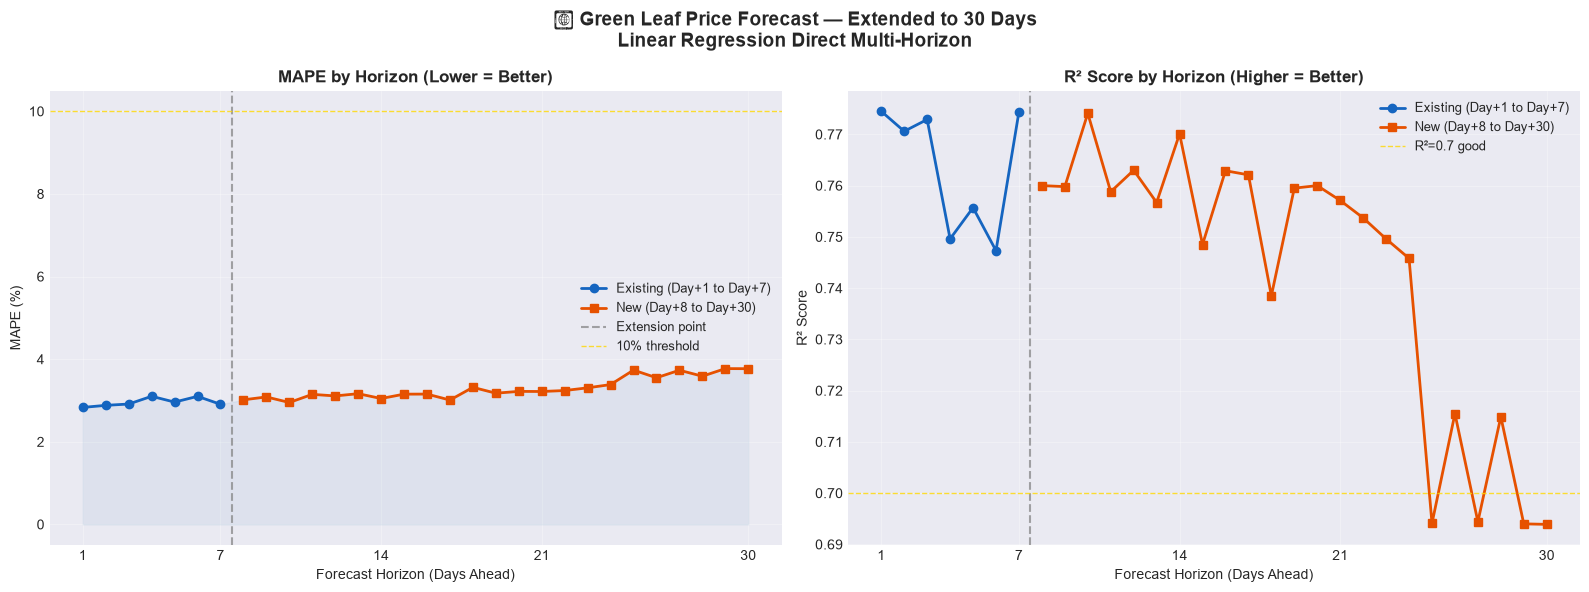

✅ Plot saved!
   plots/multistep_extended/mape_30day_full.png


In [9]:
# ============================================================
# Visual confirmation: accuracy across 30 days
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(
    '📈 Green Leaf Price Forecast — Extended to 30 Days\n'
    'Linear Regression Direct Multi-Horizon',
    fontsize=14, fontweight='bold'
)

horizons   = list(all_results.keys())
mapes      = [all_results[h]['MAPE'] for h in horizons]
r2s        = [all_results[h]['R2']   for h in horizons]

# ── Plot 1: MAPE across 30 horizons ──────────────────────
axes[0].plot(horizons[:7],  mapes[:7],
             color='#1565C0', marker='o',
             markersize=6, linewidth=2,
             label='Existing (Day+1 to Day+7)')

axes[0].plot(horizons[7:],  mapes[7:],
             color='#E65100', marker='s',
             markersize=6, linewidth=2,
             label='New (Day+8 to Day+30)')

# Mark the boundary
axes[0].axvline(x=7.5, color='gray',
                linestyle='--', linewidth=1.5,
                alpha=0.7, label='Extension point')

axes[0].axhline(y=10, color='gold',
                linestyle='--', linewidth=1,
                alpha=0.8, label='10% threshold')

axes[0].fill_between(horizons, mapes,
                     alpha=0.08, color='steelblue')

axes[0].set_title('MAPE by Horizon (Lower = Better)',
                  fontweight='bold')
axes[0].set_xlabel('Forecast Horizon (Days Ahead)')
axes[0].set_ylabel('MAPE (%)')
axes[0].set_xticks([1, 7, 14, 21, 30])
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# ── Plot 2: R² across 30 horizons ────────────────────────
axes[1].plot(horizons[:7],  r2s[:7],
             color='#1565C0', marker='o',
             markersize=6, linewidth=2,
             label='Existing (Day+1 to Day+7)')

axes[1].plot(horizons[7:],  r2s[7:],
             color='#E65100', marker='s',
             markersize=6, linewidth=2,
             label='New (Day+8 to Day+30)')

axes[1].axvline(x=7.5, color='gray',
                linestyle='--', linewidth=1.5,
                alpha=0.7)

axes[1].axhline(y=0.7, color='gold',
                linestyle='--', linewidth=1,
                alpha=0.8, label='R²=0.7 good')

axes[1].set_title('R² Score by Horizon (Higher = Better)',
                  fontweight='bold')
axes[1].set_xlabel('Forecast Horizon (Days Ahead)')
axes[1].set_ylabel('R² Score')
axes[1].set_xticks([1, 7, 14, 21, 30])
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(
    'plots/multistep_extended/mape_30day_full.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

print("✅ Plot saved!")
print("   plots/multistep_extended/mape_30day_full.png")

In [10]:
# ============================================================
# Save updated metadata
# API reads this to know supported horizons
# ============================================================

# Collect all MAPE values
mape_by_day = {
    h: all_results[h]['MAPE']
    for h in ALL_HORIZONS
}

metadata = {
    'version':            '2.0',
    'max_horizon':        30,
    'supported_horizons': [7, 14, 30],
    'all_horizons':       ALL_HORIZONS,
    'strategy':           'direct_multi_horizon',
    'model_type':         'LinearRegression',
    'feature_count':      len(FEATURE_COLS),
    'feature_cols':       FEATURE_COLS,
    'split_ratio':        SPLIT_RATIO,
    'mape_by_day':        mape_by_day,
    'avg_mape_7d':        round(
        np.mean([mape_by_day[h] for h in range(1,8)]),3),
    'avg_mape_14d':       round(
        np.mean([mape_by_day[h] for h in range(1,15)]),3),
    'avg_mape_30d':       round(
        np.mean([mape_by_day[h] for h in range(1,31)]),3),
}

# Save
joblib.dump(metadata,
            'saved_models/multistep/metadata_v2.pkl')

with open('saved_models/multistep/metadata_v2.json',
          'w') as f:
    json.dump(metadata, f, indent=2)

print("="*60)
print("   METADATA SAVED")
print("="*60)
print()
print(f"   Max horizon     : {metadata['max_horizon']} days")
print(f"   Supported UI    : 7 / 14 / 30 days")
print(f"   Avg MAPE (7d)   : {metadata['avg_mape_7d']}%")
print(f"   Avg MAPE (14d)  : {metadata['avg_mape_14d']}%")
print(f"   Avg MAPE (30d)  : {metadata['avg_mape_30d']}%")
print()
print("   Files saved:")
print("   saved_models/multistep/metadata_v2.pkl")
print("   saved_models/multistep/metadata_v2.json")
print()
print("   saved_models/multistep/ now contains:")
print("   lr_day1.pkl  → lr_day30.pkl  (30 models total)")
print("   scaler.pkl   (unchanged)")
print()
print("🎓 PRICE FORECAST TRAINING COMPLETE!")
print()
print("   NEXT STEP: Update smarttea_ai_api.py")

   METADATA SAVED

   Max horizon     : 30 days
   Supported UI    : 7 / 14 / 30 days
   Avg MAPE (7d)   : 2.956%
   Avg MAPE (14d)  : 3.015%
   Avg MAPE (30d)  : 3.217%

   Files saved:
   saved_models/multistep/metadata_v2.pkl
   saved_models/multistep/metadata_v2.json

   saved_models/multistep/ now contains:
   lr_day1.pkl  → lr_day30.pkl  (30 models total)
   scaler.pkl   (unchanged)

🎓 PRICE FORECAST TRAINING COMPLETE!

   NEXT STEP: Update smarttea_ai_api.py
